# Lecture 1: Plotting the Classics
v.ekc

Welcome to DATA 111! 😊 Today isn't about memorizing code, it's a preview of what data science *feels* like: we'll take two whole novels (one certified classic, one vampire romance) and turn them into pictures that tell a story. (Slides: KL Lecture 01 deck, slides 36–41.)

**Today's sections:**
1. Getting set up
2. Read two books, fast!
3. Counting character mentions — *Twilight*
4. Same idea, new book — *Little Women*
5. How long is a chapter?
6. Try It

---
## 1. Getting set up

Every notebook starts by importing the tools we'll use, most importantly the `datascience` package ([docs](https://data8.org/datascience/)), built for this course. Run this cell and move on; you'll get to know these lines well this semester.

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

And just to prove the notebook is alive; Python is, at minimum, a very fancy calculator:

In [ ]:
2+3

---
### Try It 1: Calculator warm-up 😊

1. Predict first, then run: what does `2 + 3 * 4` give you?

2. Now add parentheses to make the answer come out to `20`.

In [ ]:
# 1. predict, then run


In [ ]:
# 2. force it to be 20


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Python multiplies before it adds: parentheses override that.*

```python
# 1.
2 + 3 * 4      # 14, not 20!

# 2.
(2 + 3) * 4
```

</details>

---
## 2. Read two books, fast! 📚

Our two books: *Twilight* (its text file, `twilight_text.txt`, sits right next to this notebook) and *Little Women* (public domain, pulled straight off the web). We'll split each into chapters. Don't worry about *how* each line works yet, notice how **little** code it takes.

In [2]:
# Read two books, fast!

twilight_text = re.sub('\\s+', ' ', open('twilight_text.txt', encoding='utf-8').read())
twilight_chapters = twilight_text.split('CHAPTER ')[25:]   # [25:] skips the cover pages and table of contents

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]

That's the whole loading step: one local file, one download, two chapter lists. Peek at the raw material:

In [ ]:
twilight_chapters

In [ ]:
Table().with_column('Chapters', twilight_chapters)

> **Key idea:** a **Table** is how we'll organize data all semester: rows and columns, like a spreadsheet with superpowers.

---
### Try It 2: Your first table 😊

1. We just made a table of the *Twilight* chapters. Type the same kind of expression to make a table of the *Little Women* chapters.

2. Look at the bottom of each table's printout. How many chapters does each book have? Which book is "longer," by that measure?

In [ ]:
# 1. Little Women chapters as a table



*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Same pattern, different book, swap in the other chapter list.*

```python
# 1.
Table().with_column('Chapters', little_women_chapters)
```

*2. The bottom of each printout counts the rows: 24 chapters for* Twilight *(the split tucks the epilogue into the last one), 47 for* Little Women.

</details>

---
## 3. Counting character mentions — *Twilight* 🧛

If we count how many times each character's name appears in each chapter, we can watch the story unfold without reading a single page. 🔍

![Twilight Cast](https://static0.moviewebimages.com/wordpress/wp-content/uploads/2022/03/d4psbuyTcvSFjfhwrFFkv8.jpg?q=50&fit=crop&w=1056&h=594&dpr=1.5)

### 📋 Reference Table

| Code | What it does |
|---|---|
| `Table()` | makes an empty table |
| `.with_columns('label', array, ...)` | returns a table with new columns added |
| `.column('label')` | grabs one column as an array |
| `np.char.count(chapters, 'Edward')` | counts `'Edward'` in each chapter |
| `.cumsum()` | running total of an array |
| `.plot(...)` | line plot, one line per column |

In [ ]:
np.char.count(twilight_chapters, 'Edward')

In [ ]:
np.char.count(twilight_chapters, 'Jacob')

Same move for each name, now collect all three into one table:

In [ ]:
counts = Table().with_columns([
    'Edward', np.char.count(twilight_chapters, 'Edward'),
    'Jacob', np.char.count(twilight_chapters, 'Jacob'),
    'Alice', np.char.count(twilight_chapters, 'Alice'),
])
counts

In [8]:
# or! more lazily.....
names = ['Edward', 'Jacob', 'Alice']
mentions = {name: np.char.count(twilight_chapters, name) for name in names}

counts = Table().with_columns([
    'Edward', mentions['Edward'],
    'Jacob', mentions['Jacob'],
    'Alice', mentions['Alice']
])

counts

Edward,Jacob,Alice
9,0,2
16,0,1
26,0,0
22,0,1
23,0,1
7,19,1
10,11,0
14,0,0
2,6,0
10,0,1


Now the payoff: accumulate chapter by chapter and plot the story unfolding:

In [10]:
# Plot the cumulative counts:
# how many times in Chapter 1, how many times in Chapters 1 and 2, and so on.

cum_counts = Table().with_columns([
    'Edward', counts.column('Edward').cumsum(),
    'Jacob', counts.column('Jacob').cumsum(),
    'Alice', counts.column('Alice').cumsum(),
]).with_column('Chapter', np.arange(1, 25, 1))

# display our new table :)
cum_counts

Edward,Jacob,Alice,Chapter
9,0,2,1
25,0,3,2
51,0,3,3
73,0,4,4
96,0,5,5
103,19,6,6
113,30,6,7
127,30,6,8
129,36,6,9
139,36,7,10


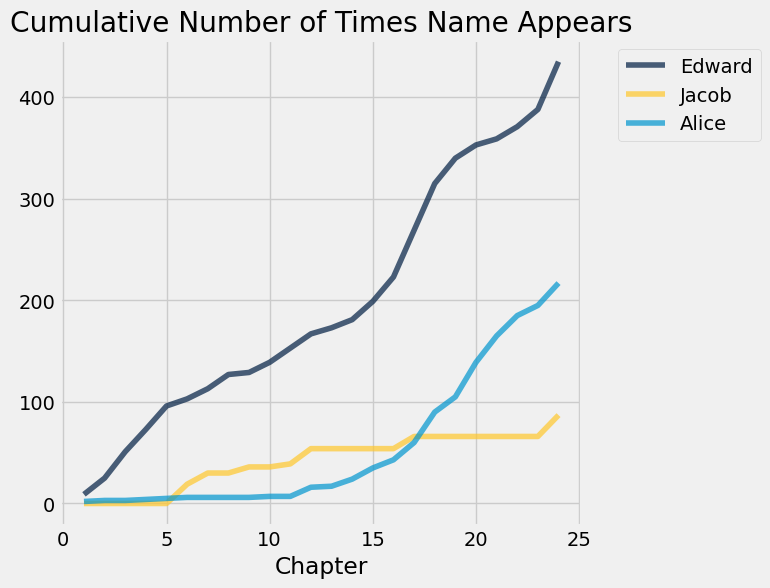

In [11]:
# plot the table!
cum_counts.plot(column_for_xticks=3)
plots.title('Cumulative Number of Times Name Appears');

> **Reading the plot:** Edward's line climbs from the very first chapter and never stops. Jacob's stays flat except for one early jump (the beach trip in Chapter 6) and a jolt in the final chapter. Alice is nearly invisible for half the book, then takes off. We just "read" a novel's plot structure from a graph. 🤯



---
### Try It 3: Sigh, vampire, murmur, velvet 😊

Names aren't the only words worth tracking. Some words carry the *mood* of a book.

1. Count how many times `'sigh'` appears in each chapter.

2. Build a cumulative-count table for all four of `'sigh'`, `'vampire'`, `'murmur'`, and `'velvet'` (plus a `'Chapter'` column) and plot it, one line per word.

3. Where does the `'vampire'` line jump, and what do you think happens in the story there? Which of the four words barely moves at all?

In [ ]:
# 1. count 'sigh' in each chapter



In [ ]:
# 2. cumulative plot of all four words, or whatever other words you want to count!


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Count, accumulate, plot: the same three moves work for any word (or any list of words).*

```python
# 1.
np.char.count(twilight_chapters, 'sigh')

# 2.
moods = Table().with_columns([
    'sigh', np.char.count(twilight_chapters, 'sigh').cumsum(),
    'vampire', np.char.count(twilight_chapters, 'vampire').cumsum(),
    'murmur', np.char.count(twilight_chapters, 'murmur').cumsum(),
    'velvet', np.char.count(twilight_chapters, 'velvet').cumsum(),
]).with_column('Chapter', np.arange(1, 25, 1))
moods.plot(column_for_xticks=4)
```

*3. The `'vampire'` line is flat until the scary stories on the beach, then leaps in Chapter 7, the night Bella puts it all together. `'velvet'` barely moves (5 mentions in the whole book, all about that voice), while `'sigh'` climbs relentlessly to 122. (Many right answers; point at the bends in your plot!)*

</details>

---
## 4. Same idea, new book — *Little Women*

The same trick works on any book. This time: the four March sisters, plus their neighbor Laurie.


![A descriptive title of your image](https://people.com/thmb/_wz8Wx8ssxcjf7Gd5jRctY1ILBw=/750x0/filters:no_upscale():max_bytes(150000):strip_icc():focal(749x0:751x2):format(webp)/little-women-121425-3543a7939ac647859d828929d06dcfab.jpg)



In [ ]:
# The chapters of Little Women

Table().with_column('Chapters', little_women_chapters)

47 chapters this time. Count all five names at once:

In [ ]:
# Counts of names in the chapters of Little Women

names = ['Amy', 'Beth', 'Jo', 'Laurie', 'Meg']
mentions = {name: np.char.count(little_women_chapters, name) for name in names}

counts = Table().with_columns([
        'Amy', mentions['Amy'],
        'Beth', mentions['Beth'],
        'Jo', mentions['Jo'],
        'Laurie', mentions['Laurie'],
        'Meg', mentions['Meg']
    ])

Five arrays, one table. Accumulate and plot, same as before:

In [ ]:
# Plot the cumulative counts

cum_counts = Table().with_columns([
    'Amy', counts.column('Amy').cumsum(),
    'Beth', counts.column('Beth').cumsum(),
    'Jo', counts.column('Jo').cumsum(),
    'Laurie', counts.column('Laurie').cumsum(),
    'Meg', counts.column('Meg').cumsum(),
]).with_column('Chapter', np.arange(1, 48, 1))
cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Name Appears');

> **Try reading this one yourself:** Who seems to be the main character? What might a line going *flat* partway through mean? 💭 You'll work with this exact plot on **Homework 1**, so it's worth lingering here.

---
### Try It 4: The March family, continued 😊

1. The sisters' mother goes by `'Marmee'`. Count her mentions in each chapter of *Little Women*.

2. Add your `'Marmee'` counts to the `counts` table as a new column: try `.with_column(...)` on the table you already have.

3. Look back at the cumulative plot above: where does Laurie's line climb fastest, and what might be happening in the story there?

In [ ]:
# 1. count 'Marmee' in each chapter


In [ ]:
# 2. add Marmee to the counts table


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*`.with_column` hands back a bigger table, the original is unchanged unless you name the result.*

```python
# 1.
np.char.count(little_women_chapters, 'Marmee')

# 2.
counts.with_column('Marmee', np.char.count(little_women_chapters, 'Marmee'))
```

*3. Many right answers, a steeper stretch means more mentions per chapter, so look for where his line pulls away from the sisters'.*

</details>

---
## 5. How long is a chapter?

Names aren't the only thing we can count. Let's measure each chapter two ways: total characters (letters, spaces, everything) and number of periods, and compare the two books.

In [ ]:
len('Data 111')

In [ ]:
len(twilight_text)

`len` counts the characters in a string, even a book-sized one. Now measure every chapter of both books:

In [ ]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

length_tw = Table().with_columns([
        'Length', [len(s) for s in twilight_chapters],
        'Periods', np.char.count(twilight_chapters, '.')
    ])
length_lw = Table().with_columns([
        'Length', [len(s) for s in little_women_chapters],
        'Periods', np.char.count(little_women_chapters, '.')
    ])

Two tables, one row per chapter. Peek at each:

In [ ]:
# The counts for Twilight

length_tw

In [ ]:
# The counts for Little Women

length_lw

Now plot them together, blue for *Twilight*, gold for *Little Women*:

In [ ]:
plots.figure(figsize=(10,10))
plots.scatter(length_tw[1], length_tw[0], color='darkblue')
plots.scatter(length_lw[1], length_lw[0], color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');

> **One dot = one chapter.** Both books show the same trend: chapters with more periods are longer, more sentences, more text. When two measurements move together like this, we call it **association**, a big idea we'll return to all semester.

---
### Try It 5: One book at a time 😊

1. Our scatter plot showed both books at once. Make the same plot for **only** *Little Women*, keep the gold color and the axis labels.

2. Find the highest dot in your plot. Roughly how long is that chapter, and about how many periods does it have?

In [ ]:
# 1. scatter for Little Women only


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*One `plots.scatter(...)` line per book, drop the one you don't want.*

```python
# 1.
plots.scatter(length_lw[1], length_lw[0], color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');
```

*2. Read the highest dot off the two axes: its height is the chapter's length, its left-right position is its period count.*

</details>

---
### Try It 6: Your turn with the classics 😊

1. The internet loves to joke about the word `'chagrin'` in *Twilight*. Count how many times it actually appears in each chapter.

2. Make a cumulative plot of the `'chagrin'` counts, chapter by chapter. Does the joke hold up?

3. Interpretation: look back at the *Little Women* plot. Which character is mentioned most by the end of the book, and roughly where does the gap open up?

In [ ]:
# 1. count 'chagrin' in each chapter


In [ ]:
# 2. cumulative plot of 'chagrin'


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The same three-step pattern (count, accumulate, plot) works for any word you're curious about.*

```python
# 1.
np.char.count(twilight_chapters, 'chagrin')

# 2.
chagrin = Table().with_columns(
    'Chagrin', np.char.count(twilight_chapters, 'chagrin').cumsum(),
    'Chapter', np.arange(1, 25, 1))
chagrin.plot('Chapter')
```

*(The verdict: 4 mentions in the whole book. The joke is bigger than the data. 😅)*

*3. Jo, her line is on top almost from the start, and the gap widens within the first dozen chapters. (Many right answers, what matters is pointing at evidence in the plot.)*

</details>

---
> **You made it through your first data science lecture!** 🎉 None of today's code is expected to stick yet, every piece gets a proper introduction in the coming weeks. What should stick: *we turned books into data, and data into stories.*

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/) • Free textbook: [Computational and Inferential Thinking](https://www.inferentialthinking.com)

### Minimal template — count & plot
```python
counts = Table().with_columns(
    'Word', np.char.count(chapters, 'word').cumsum(),
    'Chapter', np.arange(1, len(chapters) + 1))
counts.plot('Chapter')
```